In [1]:
from __future__ import annotations

import os
from typing import List, Optional, Dict
import joblib
import shutil
import subprocess
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde, t, chi2, norm

from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

# How Good is My Model? Part 5

This notebook supports [this](https://afnan-sultan.github.io/posts/2026/01/evaluation5/) blog post by plotting the different plots shown in it.

This notebook guides one through:

1. Visualizing k-fold cross-validation (CV)
2. Examples on when cross-validation does not add information and when it can lead to different conclusions than expected
3. Implementing cross-validation as proposed by Mervyn Stone in 1974
4. Explore ways to make current CV similar in spirit to Stone's proposed CV
    - Visualizing different metrics (MAE, MSE, and $R^2$) to see when they can capture Stone's CV spirit and how
    - Modifying the coefficient if determination metric ($R^2$) to better reflect the spirit of Stone's CV
5. Fully embracing Stone's CV in modern machine learning.
---
TL;DR

![image](images/evaluation_5/mindmap.png)


# 0. Recalling our setup

The below few cells are copied from the last notebook. We simply
1. Load a dataset
2. Featurize it using the RDKit descriptors

In [2]:
sns.set(style="whitegrid")
np.random.seed(42)
title_font = 18
labels_font = 16
text_font = 14
tick_font = 12

# ---- Config ----
DATASET_NAME = 'AZ'  # Change to 'Biogen' as needed
DATASET_PATHS = {
    'AZ': 'data/aqueous_solubility/by_source/solubility_az.csv',
    'Biogen': 'data/aqueous_solubility/by_source/solubility_biogen.csv'
}

images_dir = f"images/evaluation_5/{DATASET_NAME}"
os.makedirs(images_dir, exist_ok=True)

In [3]:
# ---- Load Dataset ----
df = pd.read_csv(DATASET_PATHS[DATASET_NAME])
print(f"Loaded {DATASET_NAME} dataset with {len(df)} entries.")
df.head()

Loaded AZ dataset with 1763 entries.


,SMILES,LogS
0,COc1ccc(Cl)c(Nc2ncnc3cc(OCCN4CCN(C(C)=O)CC4)cc...,-4.369572
1,CCN(C(=O)Cc1ccc(S(C)(=O)=O)cc1)C1CCN(CCC(c2ccc...,-4.159894
2,N#CC1(NC(=O)[C@@H]2CCCC[C@H]2C(=O)N2CCc3[nH]c4...,-4.130182
3,CN(C)C(=N)c1ccc(C(=O)N2CCN(S(=O)(=O)c3ccc4cc(B...,-2.879986
4,N#Cc1cccnc1-c1ccc(C(=O)Nc2ccccc2N)cc1,-4.449772


In [4]:
# ---- Featurization ----
def featurize(smiles_list):
    descriptor_names = [desc[0] for desc in Descriptors._descList if desc[0] != 'Ipc']
    calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

    features = []
    valid_indices = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            desc = calculator.CalcDescriptors(mol)
            features.append(desc)
            valid_indices.append(i)
        else:
            features.append([np.nan] * len(descriptor_names))

    return pd.DataFrame(features, columns=descriptor_names), valid_indices

# ---- Run featurization ----
X_full, valid_idx = featurize(df['SMILES'])
y_full = df.loc[valid_idx, 'LogS'].reset_index(drop=True)

# Drop rows with NaNs and reset index
X_full = X_full.dropna().reset_index(drop=True)
y_full = y_full.loc[X_full.index].reset_index(drop=True)

# Drop zero-variance features
X_full = X_full.loc[:, X_full.std() > 0]

print(f"Final dataset shape (after dropping NA and zero-variance): {X_full.shape}")

# Build a smiles series aligned to the SAME rows used by X_full/y_full
smiles_valid = df.loc[valid_idx, "SMILES"].reset_index(drop=True)

# IMPORTANT: X_full was reset_index(drop=True) after dropna, so its index is 0..n-1
# y_full was aligned to X_full.index. We align SMILES the same way:
smiles_full = smiles_valid.loc[X_full.index].reset_index(drop=True)

# Sanity check
assert len(smiles_full) == len(y_full) == len(X_full)

X_full.head()

Final dataset shape (after dropping NA and zero-variance): (1763, 194)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.532053,11.532053,0.076287,-0.076287,0.456867,14.222222,515.014,483.766,514.209531,192,...,0,0,0,0,0,0,0,0,0,0
1,13.543113,13.543113,0.034005,-3.267070,0.334738,15.000000,554.703,518.415,554.241470,208,...,0,0,0,1,0,0,0,0,0,0
2,13.503452,13.503452,0.121638,-4.436961,0.727393,24.121212,458.484,433.284,458.192961,174,...,0,0,0,0,0,0,0,0,0,0
3,13.189813,13.189813,0.133089,-3.645298,0.413431,14.939394,529.460,504.260,528.083074,172,...,0,0,1,0,0,0,0,0,0,0
4,12.302582,12.302582,0.249095,-0.249095,0.724173,9.958333,314.348,300.236,314.116761,116,...,0,0,0,0,0,0,0,0,0,0


# 1. k-fold cross-validation (CV) splits and visualization

In last posts, the data was split once into 80% train set and 20% test set. Cross-validation splits the data multiple times depending on the used scheme.

k-fold CV is one of the most common schemes. The data is split into k equal folds (here `k=5`) and then the model is trained on `k-1` folds and tested on the remaining folds, and repeated on all folds.

Below, one sees a visualization of how this look like on the AZ dataset.

In [5]:
# =============================
# Split creation (K-Fold only)
# =============================

def make_splits(
    X: pd.DataFrame | np.ndarray,
    n_splits: int = 5,
    random_state: Optional[int] = 42,
    shuffle: bool = True,
) -> List[Dict]:
    """Return a list of split dicts with keys: train_idx, val_idx, fold.

    K-Fold only.
    """
    n = len(X)
    kf = KFold(
        n_splits=n_splits,
        shuffle=shuffle,
        random_state=random_state if shuffle else None,
    )

    split_info: List[Dict] = []
    for fold, (tr, va) in enumerate(kf.split(np.arange(n)), start=1):
        split_info.append({"train_idx": tr, "val_idx": va, "fold": fold})
    return split_info


# =============================
# Visualization of splits (K-Fold only)
# =============================

def plot_splits(
    n_samples: int,
    split_info: List[Dict],
    title: str,
    images_dir: Optional[str] = None,
    filename: Optional[str] = None,
    point_size: int = 60,
):
    """Visualize K-Fold splits as rows with blue=validation, gray=train."""
    # Ensure consistent row ordering by fold
    split_info = sorted(split_info, key=lambda s: s["fold"])

    fig, ax = plt.subplots(figsize=(12, 3 + 0.5 * len(split_info)))

    for row, s in enumerate(split_info):
        colors = np.full(n_samples, "lightgray", dtype=object)
        colors[s["val_idx"]] = "tab:green"
        ax.scatter(
            range(n_samples),
            [row] * n_samples,
            c=colors,
            marker="s",
            s=point_size,
            edgecolor="k",
            linewidth=0.3,
        )

    ax.set_yticks(range(len(split_info)))
    ax.set_yticklabels([f"Fold {s['fold']}" for s in split_info])
    ax.set_title(title + "\nBlue = Validation, Gray = Train")
    ax.set_xlabel("Sample Index")
    ax.set_xlim(0, n_samples)
    ax.set_ylim(-0.5, len(split_info) - 0.5)
    plt.tight_layout()

    if images_dir and filename:
        os.makedirs(images_dir, exist_ok=True)
        plt.savefig(os.path.join(images_dir, filename), dpi=150)

    plt.show()


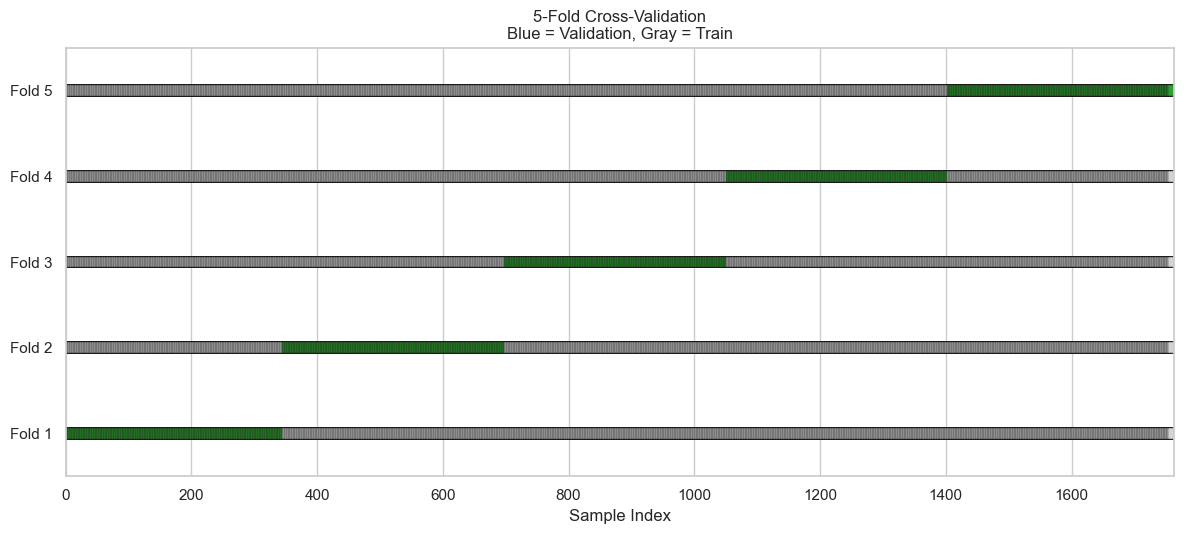

In [6]:
# KFold
n_splits = 5
splits_k = make_splits(X_full, n_splits=n_splits, shuffle=False)
plot_splits(len(X_full), splits_k, title=f"{n_splits}-Fold Cross-Validation", images_dir=images_dir, filename=f"{n_splits}-fold_CV.png")

## 5-fold CV - Random Forest

A model is trained `k` times, each time with a **slightly** different train and test sets. One ends up with multiple performance samples for the same model.

In [7]:
def run_cv_wide(X, y, splits, models, smiles=None, include_residuals=False):
    """
    Minimal CV runner that returns a WIDE df.

    Args:
      X: pd.DataFrame or np.ndarray (for sklearn models)
      y: array-like
      splits: list of dicts with keys train_idx, val_idx, fold
      models: dict {name: builder}, where builder is:
        - a class/callable returning a fresh estimator (recommended), OR
        - a sklearn estimator/pipeline instance (will be cloned)
      smiles: array-like of SMILES (needed only for chemprop model)
      include_residuals: bool

    Convention:
      - baseline model name: "y_bar"
      - chemprop model name: "chemprop"
      - everything else treated as sklearn on X
    """
    y = np.asarray(y, float)
    n = len(y)

    # fold index per sample
    fold_of = np.zeros(n, dtype=int)
    for s in splits:
        fold_of[np.asarray(s["val_idx"], int)] = int(s["fold"])

    preds = {name: np.full(n, np.nan, dtype=float) for name in models}

    for s in splits:
        tr = np.asarray(s["train_idx"], int)
        va = np.asarray(s["val_idx"], int)

        for name, builder in models.items():
            # fresh estimator each fold
            if callable(builder) and not hasattr(builder, "fit"):
                est = builder()
            elif callable(builder) and hasattr(builder, "fit") and not hasattr(builder, "get_params"):
                # e.g., passing class directly (BaselineMean)
                est = builder()
            else:
                est = clone(builder)

            if name == "chemprop":
                est.fit(np.asarray(smiles, object)[tr], y[tr])
                yhat = est.predict(np.asarray(smiles, object)[va])

            elif name == "y_bar":
                est.fit(None, y[tr])
                yhat = est.predict(np.zeros(len(va)))

            else:
                Xtr = X.iloc[tr] if hasattr(X, "iloc") else X[tr]
                Xva = X.iloc[va] if hasattr(X, "iloc") else X[va]
                est.fit(Xtr, y[tr])
                yhat = est.predict(Xva)

            preds[name][va] = np.asarray(yhat, float).reshape(-1)

    df = pd.DataFrame({"idx": np.arange(n), "fold": fold_of, "y_true": y})
    for name in models:
        df[f"pred_{name}"] = preds[name]
        if include_residuals:
            df[f"resid_{name}"] = df["y_true"] - df[f"pred_{name}"]
    return df

In [8]:
rf_res = run_cv_wide(
    X_full, y_full, splits_k,
    models={"RF": lambda: RandomForestRegressor(
            n_estimators=500, random_state=42, n_jobs=-1
        )},
    include_residuals=True
)

rf_res.head()

,idx,fold,y_true,pred_RF,resid_RF
0,0,1,-4.369572,-4.497019,0.127447
1,1,1,-4.159894,-3.763950,-0.395944
2,2,1,-4.130182,-3.800107,-0.330075
3,3,1,-2.879986,-4.614589,1.734603
4,4,1,-4.449772,-4.527105,0.077333


# 2. When isn't CV what we expect?

From last posts, we explored how to estimate a model's true performance with high confidence given passed checkpoints. We saw it was possible to estimate the full distribution from a single test set of 353 datapoints.

This full distribution is supposedly the whole possible error space for a model. Regrdless of any new unseen data, **as long as it was produced in the same way that the training data was produced**, its error must fall within this distribution.

Below, we see an example where one fold's error sample estimated a true distribution. Consequently, all error samples from all other folds fell perfectly within the limits of this estimated distribution.

In [9]:
def _residual_ci_stats(residuals, alpha=0.05):
    r = np.asarray(pd.Series(residuals).dropna().values, float)
    if r.size == 0:
        raise ValueError("No residuals to plot.")
    n = len(r)
    x_bar = r.mean()
    s = r.std(ddof=1)
    sem = s / np.sqrt(n)
    t_crit = t.ppf(1 - alpha / 2, df=n - 1)
    ci_lower = x_bar - t_crit * sem
    ci_upper = x_bar + t_crit * sem

    df_ = n - 1
    s2 = np.var(r, ddof=1)
    chi2_lower = chi2.ppf(1 - alpha / 2, df_)
    chi2_upper = chi2.ppf(alpha / 2, df_)
    var_lower = (df_ * s2) / chi2_lower
    var_upper = (df_ * s2) / chi2_upper
    std_lower = np.sqrt(var_lower)
    std_upper = np.sqrt(var_upper)

    return {
        "n": n,
        "x_bar": x_bar,
        "ci_mean": (ci_lower, ci_upper),
        "std_CI": (std_lower, std_upper),
        "var_CI": (var_lower, var_upper),
        "min": r.min(),
        "max": r.max(),
        "residuals": r,
    }


def plot_fold_distribution_estimation_wide(
    df_wide: pd.DataFrame,
    resid_col: str,                # e.g. "resid_RF"
    estimate_fold: int = 1,        # fold used to estimate CI/params
    fold_col: str = "fold",
    alpha: float = 0.05,
    best_mean: float = 0.0,
    title: str = None,
    savepath: str = None,
    show: bool = True,
):
    """
    Plot scheme:
      - Thick solid "true/estimated" Normal curve (from estimate_fold stats) per panel
      - Overlay ALL folds as dashed pastel KDEs
      - Draw 5% significance thresholds (two-sided: alpha/2 and 1-alpha/2) as vertical lines
      - Mark each fold's mean as a dot placed ON its KDE (y = KDE(mean))
    """
    if title is None:
        title = f"Estimated Distributions — params from fold {estimate_fold}, overlay all folds"

    # Stats estimated from chosen fold
    est_r = df_wide.loc[df_wide[fold_col] == estimate_fold, resid_col]
    s_est = _residual_ci_stats(est_r, alpha=alpha)

    ci_lower, ci_upper = s_est["ci_mean"]
    std_lower, std_upper = s_est["std_CI"]

    case_titles = ["Best Case", "Worst — Underestimating", "Worst — Overestimating"]
    cases = [
        ("best",       best_mean, std_lower),
        ("worst_low",  ci_lower,  std_upper),
        ("worst_high", ci_upper,  std_upper),
    ]

    # Use ALL folds to set common x-range
    all_r = np.asarray(df_wide[resid_col].dropna().values, float)
    x_vals = np.linspace(all_r.min() - 1, all_r.max() + 1, 600)

    folds = sorted(df_wide[fold_col].unique().tolist())
    pastel = sns.color_palette("pastel", n_colors=len(folds))

    # Precompute KDEs + means per fold so dots land on KDE properly
    fold_kde = {}
    fold_mean = {}
    for f in folds:
        r_f = np.asarray(df_wide.loc[df_wide[fold_col] == f, resid_col].dropna().values, float)
        if len(r_f) < 2:
            continue
        fold_kde[f] = gaussian_kde(r_f)
        fold_mean[f] = float(np.mean(r_f))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=False)

    for ax, (case_name, mu, sigma), ttl in zip(axes, cases, case_titles):
        # 1) Overlay all folds as dashed pastel KDEs
        for c, f in zip(pastel, folds):
            r_f = df_wide.loc[df_wide[fold_col] == f, resid_col].dropna().values
            if len(r_f) < 2:
                continue
            sns.kdeplot(
                r_f,
                ax=ax,
                color=c,
                linewidth=1.6,
                linestyle="--",
                alpha=0.9
            )

        # 2) Thick "true/estimated" parametric distribution line
        pdf = norm.pdf(x_vals, loc=mu, scale=sigma)
        ax.plot(
            x_vals, pdf,
            color="black",
            linewidth=3.2,
            linestyle="-",
            label=f"{ttl} (from fold {estimate_fold})"
        )

        # 3) 5% significance thresholds (two-sided)
        x_lo = norm.ppf(alpha / 2, loc=mu, scale=sigma)
        x_hi = norm.ppf(1 - alpha / 2, loc=mu, scale=sigma)
        ax.axvline(x_lo, linewidth=2.0, linestyle=":", alpha=0.9, label = f"P-val < {alpha:.2f}")
        ax.axvline(x_hi, linewidth=2.0, linestyle=":", alpha=0.9)

       # 4) Mean dot per fold placed ON the fold KDE curve
        for c, f in zip(pastel, folds):
            if f not in fold_kde:
                continue
            m = fold_mean[f]
            y_at_m = fold_kde[f]([m])[0]   # <-- fix: returns scalar
            ax.scatter([m], [y_at_m], s=55, color=c, edgecolor="black", linewidth=0.6, zorder=5)


        # Also show the estimation fold empirical mean (optional, subtle)
        ax.axvline(s_est["x_bar"], color="black", linestyle="--", linewidth=1.6, alpha=0.7)

        ax.set_title(ttl, fontsize=14)
        ax.set_xlabel("Residual")
        ax.set_ylabel("Density")

        ax.legend(fontsize=9, loc="upper left")

    # Legend for folds (dashed pastel lines)
    fold_handles = [Line2D([], [], color=c, lw=2, ls="--", label=f"Fold {f}") for c, f in zip(pastel, folds)]
    fig.legend(handles=fold_handles, loc="center right", bbox_to_anchor=(1.02, 0.5),
               frameon=False, fontsize=12)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 0.93, 0.95])

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    if show:
        plt.show()

    return {
        "estimate_fold": estimate_fold,
        "mean_CI": s_est["ci_mean"],
        "std_CI": s_est["std_CI"],
        "var_CI": s_est["var_CI"],
    }, (fig, axes)


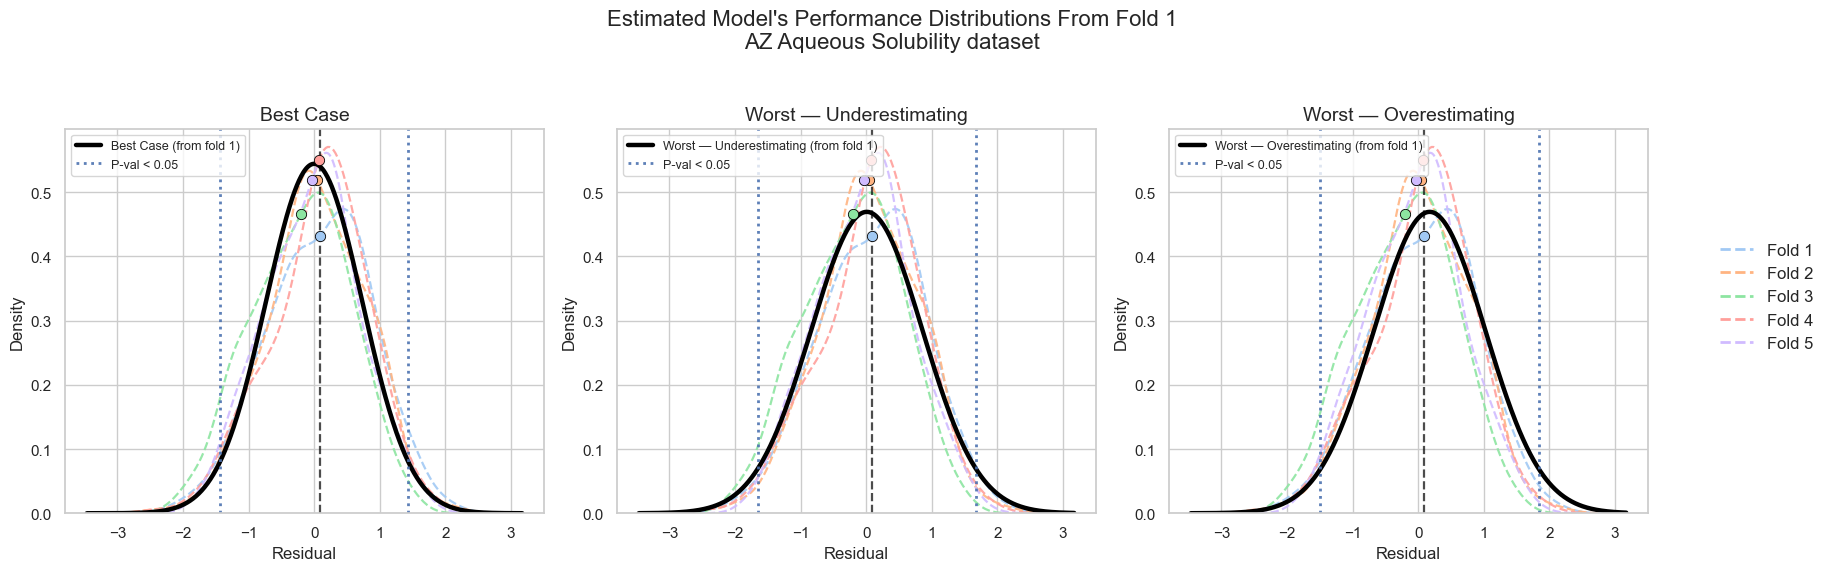

{'estimate_fold': 1,
 'mean_CI': (0.01043587190992272, 0.17523901545834114),
 'std_CI': (0.733087929090955, 0.8499774787170338),
 'var_CI': (0.537417911778865, 0.7224617143261656)}

In [10]:
ci, _ = plot_fold_distribution_estimation_wide(
    rf_res,
    resid_col="resid_RF",
    estimate_fold=1,   # pick any fold to estimate from
    alpha=0.05,
    #best_mean=0.0,
    title=f"Estimated Model's Performance Distributions From Fold 1\n{DATASET_NAME} Aqueous Solubility dataset",
    savepath=os.path.join(images_dir, "fold_estimation.png"),
)
ci


## A confusing CV behavior

Ther other dataset one can experiment with in this code is the `BioGen` dataset. If one does 5-fold CV, estimates the distribution from one fold, and plots the error of the other folds, one fold will show outlier behavior. This sample is significantly different from the estimated distribution because its mean is located with the tail (least frequent 5% of the distribution).

![image](images/evaluation_5/Biogen/fold_estimation.png)

This does not indicate that the model is performing somewhere between the estimation of the first fold and this outlier fold. It only means that this fold was very different from the other ones. It migh have contained novel molecules or values that the model was not trained to predict.

So, judging whether the model failed on this fold or not needs to be assessed only after asserting that this fold was not violating the i.i.d. conditions.

# 3. CV as proposed by Mervyn Stone in 1974

Mervyn Stone was the first one to formalize cross-validation for a tool to decide with model is best suiting a model. However, the way he proposed it is quite different from the way we do it nowadays.

The current CV trains different models and compares their performance to each other independently. Then, a researcher picks one of these models. However, Mervyn envisioned his CV as a tool to guide one through three decisions
1. New model is not improving over a baseline
2. New model is fully trusted over a baseline (maybe make as the new baseline?)
3. New model is partially helpful. Integrate with the baseline.

The way Stone's CV answer these questions is by providing an equation the governs the interaction between a baseline model's prediction and a new model's prediction via an $\alpha$ factor.

$$
\hat{y}_{\text{final}} = (1 - \alpha)\hat{y}_{\text{baseline}} + \alpha \hat{y}_{\text{new model}}
$$

In Stone's work, the baseline was defined as the most stable estimator of a distribution, its mean ($\bar{y}$) implemented below.


In [11]:
class BaselineMean:
    """Predicts mean(y_train) for every sample."""
    def fit(self, X, y):
        self.m = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.m, dtype=float)

baseline_res = run_cv_wide(
    X_full, y_full, splits_k,
    models={r"$\bar{y}$": lambda: BaselineMean()},
    include_residuals=True
)

baseline_res.head()

,idx,fold,y_true,pred_$\bar{y}$,resid_$\bar{y}$
0,0,1,-4.369572,-4.508496,0.138924
1,1,1,-4.159894,-4.508496,0.348602
2,2,1,-4.130182,-4.508496,0.378314
3,3,1,-2.879986,-4.508496,1.628510
4,4,1,-4.449772,-4.508496,0.058724


The $\alpha$ factor is what is being tested during CV to determine what value it should take from 0 to 1.
- $\alpha = 0$: ignore new model
- $\alpha = 1$: ignore baseline
- $0< \alpha < 1$: use both models

Below is the implementation of estimating the $\alpha$ in Stone's CV

In [12]:
def stone_cv_alpha_path_from_preds(
    baseline_df: pd.DataFrame,
    model_df: pd.DataFrame,
    baseline_pred_col: str,   # e.g. "pred_y_bar" or "pred_$\\bar{y}$"
    model_pred_col: str,      # e.g. "pred_RF"
    alphas=None,
    loss="mse",
    y_col="y_true",
    fold_col="fold",
    idx_col="idx",
):
    if alphas is None:
        alphas = np.linspace(0, 1, 101)
    alphas = np.asarray(alphas, dtype=float)

    # loss fn
    if callable(loss):
        loss_fn = loss
        loss_name = getattr(loss, "__name__", "loss")
    else:
        loss = loss.lower()
        if loss == "mse":
            loss_fn = mean_squared_error
            loss_name = "MSE"
        elif loss == "mae":
            loss_fn = mean_absolute_error
            loss_name = "MAE"
        else:
            raise ValueError("loss must be 'mse', 'mae', or a callable.")

    # align rows by idx (and keep fold/y_true from baseline_df)
    df = baseline_df[[idx_col, fold_col, y_col, baseline_pred_col]].merge(
        model_df[[idx_col, model_pred_col]],
        on=idx_col,
        how="inner",
    )

    split_folds = sorted(df[fold_col].unique())
    n_folds = len(split_folds)
    loss_matrix = np.empty((n_folds, len(alphas)), dtype=float)

    for i, f in enumerate(split_folds):
        dff = df[df[fold_col] == f]
        y_true = dff[y_col].to_numpy(dtype=float)
        y_base = dff[baseline_pred_col].to_numpy(dtype=float)
        y_model = dff[model_pred_col].to_numpy(dtype=float)

        # y_final(alpha) = (1-alpha)*y_base + alpha*y_model
        y_final = (1.0 - alphas)[:, None] * y_base[None, :] + alphas[:, None] * y_model[None, :]

        for j in range(len(alphas)):
            loss_matrix[i, j] = loss_fn(y_true, y_final[j])

    mean_loss = loss_matrix.mean(axis=0)
    min_loss = loss_matrix.min(axis=0)
    max_loss = loss_matrix.max(axis=0)
    best_j = int(np.argmin(mean_loss))

    return {
        "alphas": alphas,
        "loss_matrix": loss_matrix,
        "mean_loss": mean_loss,
        "min_loss": min_loss,
        "max_loss": max_loss,
        "best_alpha": float(alphas[best_j]),
        "best_loss": float(mean_loss[best_j]),
        "loss_name": loss_name,
    }


In [13]:
results = stone_cv_alpha_path_from_preds(
    baseline_df=baseline_res,
    model_df=rf_res,
    baseline_pred_col=r"pred_$\bar{y}$",  # or whatever you saw from the print above
    model_pred_col="pred_RF",
    alphas=np.linspace(0, 1, 101),
    loss="mse",
)

results["best_alpha"], results["best_loss"]


(1.0, 0.5637430933493044)

## Case Ingore BaseLine

Below, we plot the predictions of each fold at each value of $\alpha$ when comparing the $\bar{y}$ baseline to a random forest (RF) model on the AZ dataset.

The best average predictions are achieved at $\alpha = 1$. This means that RF's predictions are always better that the simple $\bar{y}$ model.

In [14]:
def plot_stone_cv_alpha_path(
    results,
    title="Stone CV: CV Loss vs α",
    show_per_fold=True,
    per_fold_alpha=0.25,
    mean_linewidth=3.5,
    show_range_band=True,       # min–max envelope (descriptive, NOT CI)
    range_band_alpha=0.12,
    show_baseline_line=True,
    annotate_best=True,
    images_dir=None,
    filename=None,
    dpi=200,
    show=True,
):
    # compatible with results from stone_cv_alpha_path_from_preds
    alphas = np.asarray(results["alphas"], float)
    L = np.asarray(results["loss_matrix"], float)
    mean_loss = np.asarray(results["mean_loss"], float)
    min_loss = np.asarray(results["min_loss"], float)
    max_loss = np.asarray(results["max_loss"], float)
    best_alpha = float(results["best_alpha"])
    best_loss = float(results["best_loss"])
    loss_name = results.get("loss_name", "Loss")

    fig, ax = plt.subplots(figsize=(10, 6))

    # per-fold curves
    if show_per_fold:
        for i in range(L.shape[0]):
            ax.plot(alphas, L[i], linewidth=1.0, alpha=per_fold_alpha)

    # fold range band
    if show_range_band:
        ax.fill_between(alphas, min_loss, max_loss, alpha=range_band_alpha, label="Fold range (min–max)")

    # mean curve
    ax.plot(alphas, mean_loss, linewidth=mean_linewidth, label=f"Mean CV {loss_name}")

    # baseline α=0 (nearest)
    baseline_mean = None
    if show_baseline_line:
        j0 = int(np.argmin(np.abs(alphas - 0.0)))
        baseline_mean = float(mean_loss[j0])
        ax.axhline(baseline_mean, linestyle="--", linewidth=1.5, alpha=0.85, label="Baseline (α≈0)")

    # best alpha marker
    if annotate_best:
        ax.axvline(best_alpha, linestyle="--", linewidth=1.5, alpha=0.9)
        ax.scatter([best_alpha], [best_loss], s=70, zorder=5)

        if show_baseline_line and baseline_mean is not None:
            improvement = baseline_mean - best_loss
            ax.text(
                0.02, 0.02,
                f"α* = {best_alpha:.3g}\nΔ = baseline - best = {improvement:.4g}",
                transform=ax.transAxes,
                va="bottom", ha="left",
                fontsize=10,
            )

    ax.set_title(title)
    ax.set_xlabel("α (shrinkage toward baseline)")
    ax.set_ylabel(f"CV {loss_name}")
    ax.set_xlim(float(alphas.min()), float(alphas.max()))
    ax.legend()
    fig.tight_layout()

    # save
    if images_dir and filename:
        os.makedirs(images_dir, exist_ok=True)
        fig.savefig(os.path.join(images_dir, filename), dpi=dpi, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


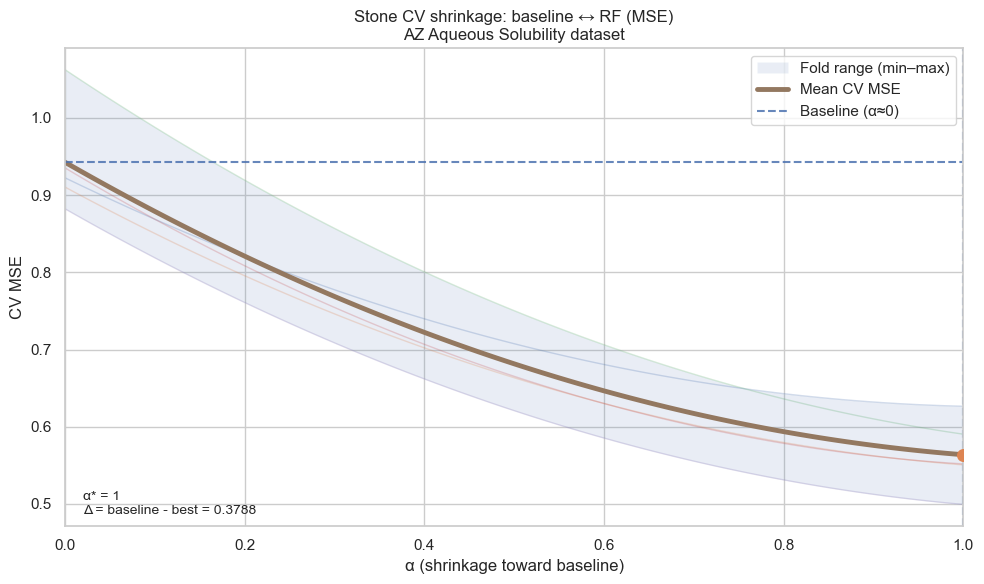

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Stone CV shrinkage: baseline ↔ RF (MSE)\nAZ Aqueous Solubility dataset'}, xlabel='α (shrinkage toward baseline)', ylabel='CV MSE'>)

In [15]:
plot_stone_cv_alpha_path(results, title=f"Stone CV shrinkage: baseline ↔ RF (MSE)\n{DATASET_NAME} Aqueous Solubility dataset", images_dir=images_dir, filename="Stone_cv.png")

# 4. Modern CV with the spirit of Stone's CV - Anchored in baseline comparison

Even though the current CV is not what Stone envisioned, it can still carry his spirit without changing any implementation. The only requirement is to base analysis in baselines. Good baselines.

We will start with using the same baseline Stone proposed, which is the $\bar{y}$, and see how it can be used in comparison to other models.

For a wide view of models, we will see a
- Basic model: Linear regression (LR)
- Logical model (but not good at extrapolation): Random forest (RF)
- Advanced generic model: multi-layer perceptron (MLP)
- Advanced specific model: Message-passing graph neural network (named ChemProp)

## Proper data handling for linear regression and multi-layer perceptron models

A random forest model needs little handling before passing the features to the model. However, LR and MLP require scaling the features so that they do not destabilize the math in these models.

However, scaling cannot be applied the same to all features. E.g., a continuous feature's scaling is different than a binary feature. So, one needs to define the type of feature then the proper scaling to apply to it.

The last notebook explored this process in detail. Here, we upload the file produced from these analyses and we use them directly here.

In [16]:
def load_feature_types(col_groups_joblib_path):
    return joblib.load(col_groups_joblib_path)

def build_preprocess_from_groups(col_groups):
    transformers = []

    cont = col_groups.get("continuous", [])
    count = col_groups.get("count", [])
    ordinal = col_groups.get("ordinal", [])
    binary = col_groups.get("binary", [])

    if len(cont) > 0:
        transformers.append(("cont", StandardScaler(), cont))

    if len(count) > 0:
        transformers.append((
            "count_log",
            Pipeline([
                ("log1p", FunctionTransformer(np.log1p, validate=False)),
                ("scale", StandardScaler()),
            ]),
            count
        ))

    if len(ordinal) > 0:
        transformers.append(("ordinal", StandardScaler(), ordinal))

    if len(binary) > 0:
        transformers.append(("binary", "passthrough", binary))

    return ColumnTransformer(transformers, remainder="drop")

def build_sklearn_models(preprocess, which=("linreg", "mlp"), seed=42):
    """
    Returns dict {name: builder} where builder() -> fresh estimator/pipeline.
    preprocess must be a ColumnTransformer built for X (DataFrame with those columns).
    """
    from sklearn.base import clone as sk_clone

    models = {}

    if "linreg" in which:
        models["linreg"] = lambda: Pipeline([
            ("preprocess", sk_clone(preprocess)),
            ("model", LinearRegression()),
        ])

    if "mlp" in which:
        models["mlp"] = lambda: Pipeline([
            ("preprocess", sk_clone(preprocess)),
            ("model", MLPRegressor(
                hidden_layer_sizes=(256, 128),
                early_stopping=True,
                max_iter=2000,
                random_state=seed,
            )),
        ])

    return models

In [17]:
# Build preprocess
path = os.path.join("images/evaluation_4", "rdkit_feature_types_col_groups.joblib")

col_groups_raw = load_feature_types(path)

available = set(X_full.columns)
missing = {k: sorted(set(v) - available) for k, v in col_groups_raw.items()}
print({k: len(m) for k, m in missing.items()})

col_groups = {k: [c for c in v if c in available] for k, v in col_groups_raw.items()}
preprocess = build_preprocess_from_groups(col_groups)

# Build model builders
models = {}
models.update(build_sklearn_models(preprocess, which=("linreg","mlp"), seed=42))

# Run CV
new_models = run_cv_wide(
    X_full, y_full, splits_k,
    models=models,
    include_residuals=True
)

new_models.head()

{'binary': 0, 'ordinal': 0, 'count': 0, 'continuous': 0}


,idx,fold,y_true,pred_linreg,resid_linreg,pred_mlp,resid_mlp
0,0,1,-4.369572,-5.049062,0.679490,-4.704231,0.334659
1,1,1,-4.159894,-4.601217,0.441323,-3.547904,-0.611989
2,2,1,-4.130182,-4.162019,0.031837,-3.713088,-0.417094
3,3,1,-2.879986,-4.194286,1.314300,-4.212630,1.332645
4,4,1,-4.449772,-4.593635,0.143864,-4.340134,-0.109637


## Training ChemProp - A message-passing graph neural network model

ChemProb converts a molecule into a graph where nodes are atoms and edges are bonds. Each atom is described by a set of characteristic features, then these features get passed through the graph (this is the extent of what I can say about this model given my limited knowledge).

In [18]:
def _check_chemprop_cli():
    for cmd in ["chemprop_train", "chemprop_predict"]:
        if shutil.which(cmd) is None:
            raise RuntimeError(
                f"Could not find `{cmd}` in PATH. "
                "Install chemprop==1.6.1 so chemprop_train/chemprop_predict are available."
            )


def _read_pred_column(preds_csv: Path) -> np.ndarray:
    """Grab last numeric column from chemprop preds CSV."""
    dfp = pd.read_csv(preds_csv)
    num_cols = [c for c in dfp.columns if pd.api.types.is_numeric_dtype(dfp[c])]
    if not num_cols:
        raise ValueError(f"No numeric prediction column found in {preds_csv}. Columns: {dfp.columns.tolist()}")
    return dfp[num_cols[-1]].to_numpy(dtype=float)


class ChempropCLIWrapper:
    """
    Minimal wrapper around chemprop v1 CLI.

    - fit(smiles_train, y_train): writes train/val CSVs, runs chemprop_train, stores checkpoint dir
    - predict(smiles_test): writes test CSV, runs chemprop_predict, returns predictions

    Internal val is carved from the training set (like your working code).
    """

    def __init__(
        self,
        work_dir=None,               # base dir for artifacts; if None, uses temp dir per fold
        random_state=42,
        internal_val_frac=0.10,
        epochs=30,
        batch_size=50,
        metric="mae",
        extra_metrics=("r2",),
        quiet=True,
        smiles_col="SMILES",
        target_col="LogS",
    ):
        _check_chemprop_cli()

        self.work_dir = Path(work_dir) if work_dir is not None else None
        self.random_state = int(random_state)
        self.internal_val_frac = float(internal_val_frac)
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.metric = str(metric)
        self.extra_metrics = tuple(extra_metrics) if extra_metrics else ()
        self.quiet = bool(quiet)
        self.smiles_col = smiles_col
        self.target_col = target_col

        # populated in fit()
        self._fold_dir = None
        self._save_dir = None
        self._tmp_created = False

    def fit(self, smiles_train, y_train):
        smiles_train = pd.Series(smiles_train).reset_index(drop=True)
        y_train = pd.Series(y_train).reset_index(drop=True)

        # Make a working folder for THIS fit call (i.e., this fold)
        if self.work_dir is None:
            self._fold_dir = Path(tempfile.mkdtemp(prefix="chemprop_fold_"))
            self._tmp_created = True
        else:
            self.work_dir.mkdir(parents=True, exist_ok=True)
            # unique-ish folder to avoid collisions if called repeatedly
            self._fold_dir = self.work_dir / f"fold_seed_{self.random_state}_{np.random.randint(1e9)}"
            self._fold_dir.mkdir(parents=True, exist_ok=True)

        train_csv = self._fold_dir / "train.csv"
        val_csv   = self._fold_dir / "val.csv"
        self._save_dir = self._fold_dir / "ckpt"
        self._save_dir.mkdir(parents=True, exist_ok=True)

        # carve internal val from training fold
        rng = np.random.default_rng(self.random_state)
        idx = np.arange(len(smiles_train))
        perm = rng.permutation(idx)
        n_val = max(1, int(round(self.internal_val_frac * len(idx))))
        val_idx = perm[:n_val]
        tr_idx  = perm[n_val:]

        pd.DataFrame({self.smiles_col: smiles_train.iloc[tr_idx], self.target_col: y_train.iloc[tr_idx]}).to_csv(train_csv, index=False)
        pd.DataFrame({self.smiles_col: smiles_train.iloc[val_idx], self.target_col: y_train.iloc[val_idx]}).to_csv(val_csv, index=False)

        cmd_train = [
            "chemprop_train",
            "--data_path", str(train_csv),
            "--separate_val_path", str(val_csv),
            "--dataset_type", "regression",
            "--smiles_column", self.smiles_col,
            "--target_columns", self.target_col,
            "--save_dir", str(self._save_dir),
            "--epochs", str(self.epochs),
            "--batch_size", str(self.batch_size),
            "--metric", self.metric,
            "--seed", str(self.random_state),
        ]
        if self.extra_metrics:
            cmd_train += ["--extra_metrics"] + list(self.extra_metrics)
        if self.quiet:
            cmd_train += ["--quiet"]

        subprocess.run(cmd_train, check=True)
        return self

    def predict(self, smiles_test):
        smiles_test = pd.Series(smiles_test).reset_index(drop=True)

        test_csv  = self._fold_dir / "test.csv"
        preds_csv = self._fold_dir / "preds.csv"

        # chemprop_predict doesn't require target column, but it's fine either way
        pd.DataFrame({self.smiles_col: smiles_test}).to_csv(test_csv, index=False)

        cmd_pred = [
            "chemprop_predict",
            "--test_path", str(test_csv),
            "--checkpoint_dir", str(self._save_dir),
            "--preds_path", str(preds_csv),
        ]
        subprocess.run(cmd_pred, check=True)

        return _read_pred_column(preds_csv)

    def cleanup(self):
        """Optional manual cleanup if you used temp folders."""
        if self._tmp_created and self._fold_dir is not None:
            shutil.rmtree(self._fold_dir, ignore_errors=True)
            self._fold_dir = None
            self._save_dir = None
            self._tmp_created = False


In [19]:
chemprop_models = {
    "chemprop": lambda: ChempropCLIWrapper(
        work_dir="chemprop_runs",      # or None for temp per fold
        random_state=42,               # IMPORTANT: run_cv_wide doesn't pass fold, so we vary seed below
        internal_val_frac=0.10,
        epochs=30,
        batch_size=50,
        metric="mae",
        extra_metrics=("r2",),
        quiet=True,
        smiles_col="SMILES",
        target_col="LogS",
    )
}

chemprop_res = run_cv_wide(
    X_full, y_full, splits_k,
    models=chemprop_models,
    smiles=smiles_full
)


1269it [00:00, 411041.14it/s]
100%|██████████| 1269/1269 [00:00<00:00, 8622.26it/s]
Fold 0
141it [00:00, 477703.44it/s]
100%|██████████| 21/21 [00:01<00:00, 12.52it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.39it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.81it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.14it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.21it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.32it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.34it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.11it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.30it/s]
                                               
 95%|█████████▌|

Loading training args
Setting molecule featurization parameters to default.
Loading data
Validating SMILES
Test size = 353
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


/Users/afnan_sultan/miniconda3/envs/emtrl_datasail/lib/python3.10/site-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, ma

Saving predictions to chemprop_runs/fold_seed_42_534895718/preds.csv
Elapsed time = 0:00:42


1269it [00:00, 395318.76it/s]
100%|██████████| 1269/1269 [00:00<00:00, 8636.30it/s]
Fold 0
141it [00:00, 486346.11it/s]
 95%|█████████▌| 20/21 [00:01<00:00, 11.69it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.54it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.49it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.34it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.83it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.99it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.45it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.06it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 13.23it/s]
                                               
 95%|█████████▌|

...

Saving predictions to chemprop_runs/fold_seed_42_787846414/preds.csv
Elapsed time = 0:00:42


1270it [00:00, 417916.69it/s]
100%|██████████| 1270/1270 [00:00<00:00, 8541.03it/s]
Fold 0
141it [00:00, 478089.62it/s]
 95%|█████████▌| 20/21 [00:01<00:00, 11.40it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.73it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.86it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.98it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 16.41it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.81it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.99it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.97it/s]
                                               
 95%|█████████▌| 20/21 [00:01<00:00, 15.87it/s]
                                               
 95%|█████████▌|

Loading training args
Setting molecule featurization parameters to default.
Loading data
Validating SMILES
Test size = 352
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".


/Users/afnan_sultan/miniconda3/envs/emtrl_datasail/lib/python3.10/site-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, ma

Saving predictions to chemprop_runs/fold_seed_42_996406378/preds.csv
Elapsed time = 0:00:42


## Merge all models in one dataframe

Now we merge the predictions and residuals of all models in one dataframe to use later for visualization and analysis

In [20]:
def merge_cv_wide(*dfs):
    """
    Merge multiple run_cv_wide outputs into one wide df.
    Keeps idx/fold/y_true from the first df, and appends all pred_/resid_ cols from others.
    """
    base = dfs[0][["idx", "fold", "y_true"]].copy()

    for df in dfs:
        cols = ["idx"] + [c for c in df.columns if c.startswith("pred_") or c.startswith("resid_")]
        base = base.merge(df[cols], on="idx", how="left")

    # optional: nicer column order
    pred_cols = sorted([c for c in base.columns if c.startswith("pred_")])
    resid_cols = sorted([c for c in base.columns if c.startswith("resid_")])
    base = base[["idx", "fold", "y_true"] + pred_cols + resid_cols]

    return base


In [21]:
all_models = merge_cv_wide(
    baseline_res,
    rf_res,
    new_models,
    chemprop_res
)

all_models.head()


,idx,fold,y_true,pred_$\bar{y}$,pred_RF,pred_chemprop,pred_linreg,pred_mlp,resid_$\bar{y}$,resid_RF,resid_linreg,resid_mlp
0,0,1,-4.369572,-4.508496,-4.497019,-4.672657,-5.049062,-4.704231,0.138924,0.127447,0.679490,0.334659
1,1,1,-4.159894,-4.508496,-3.763950,-4.425329,-4.601217,-3.547904,0.348602,-0.395944,0.441323,-0.611989
2,2,1,-4.130182,-4.508496,-3.800107,-3.705424,-4.162019,-3.713088,0.378314,-0.330075,0.031837,-0.417094
3,3,1,-2.879986,-4.508496,-4.614589,-5.394819,-4.194286,-4.212630,1.628510,1.734603,1.314300,1.332645
4,4,1,-4.449772,-4.508496,-4.527105,-4.771891,-4.593635,-4.340134,0.058724,0.077333,0.143864,-0.109637


## Anchoring comparison in baseline by two methods

To stay truthful to Stone's CV, one needs to compare their models to a baseline. As we defined the baseline to be the $\bar{y}, one needs to know how to incorporate it in the analysis.

If one uses a metric like mean absolute error (MAE) or mean squared error (MSE), then one needs to calculate the MAE and MSE for the baseline model and include it as a viable model.

If one uses a metric like the coefficient of determination $R^2$, then the equation inherently compares the MSE of a model to the MSE of $\bar{y}$. So, the value of the metric already explains how much better (or worse) does a model perform relative to the basic baseline.

The below GIF visualizes the three metrics to lock their intuition if needed.

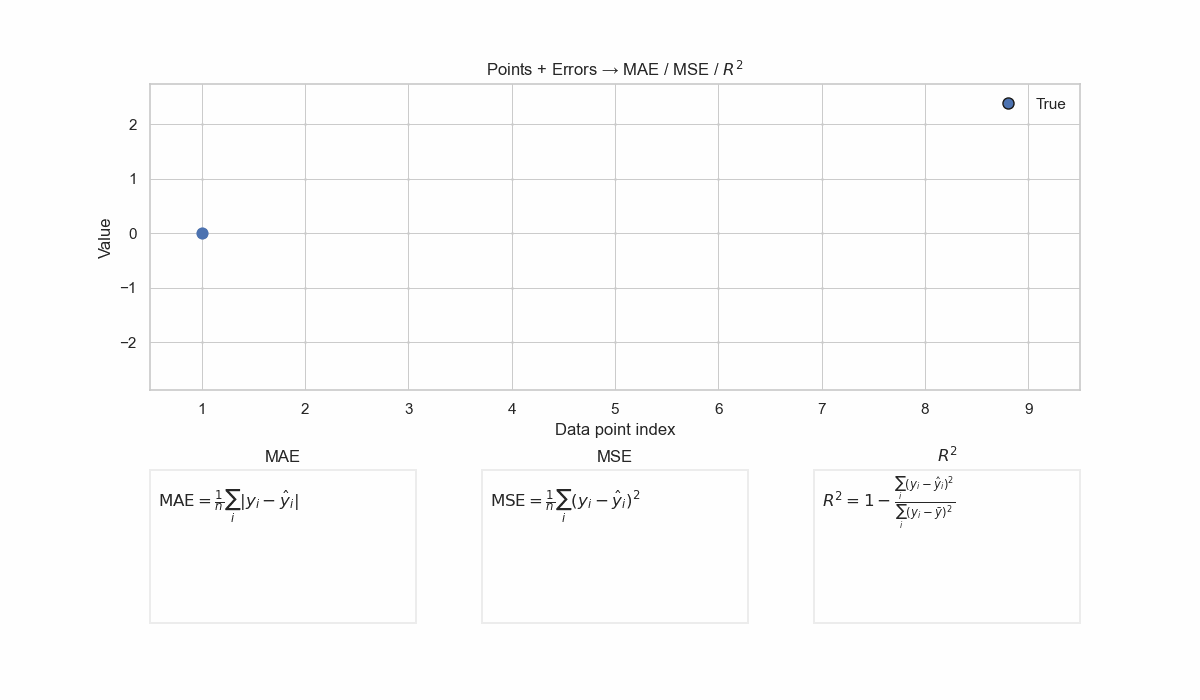

In [22]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

# ---------------------------
# Config
# ---------------------------
os.makedirs(images_dir, exist_ok=True)

BLUE = "tab:blue"
BLACK = "k"
GRAY = "0.35"

# ---------------------------
# Data (farther predictions)
# ---------------------------
rng = np.random.default_rng(7)
n = 9
x = np.arange(1, n + 1)
y_true = rng.normal(loc=0.0, scale=1.0, size=n)

# hypothetical model farther away
y_pred = y_true + rng.normal(loc=0.0, scale=1.10, size=n)

y_mean = float(np.mean(y_true))
y_pred_mean = np.full(n, y_mean)

res_model = y_true - y_pred
res_mean  = y_true - y_pred_mean

abs_err = np.abs(res_model)
sq_err  = res_model**2
sq_base = res_mean**2

# ---------------------------
# Layout
# ---------------------------
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[3.2, 1.6], hspace=0.35, wspace=0.25)

ax_top = fig.add_subplot(gs[0, :])
ax_mae = fig.add_subplot(gs[1, 0])
ax_mse = fig.add_subplot(gs[1, 1])
ax_r2  = fig.add_subplot(gs[1, 2])

# ---------------------------
# Top axis (NO mean horizontal line)
# ---------------------------
ax_top.set_title("Points + Errors → MAE / MSE / $R^2$")
ax_top.set_xlabel("Data point index")
ax_top.set_ylabel("Value")
ax_top.set_xlim(0.5, n + 0.5)

ymin = min(y_true.min(), y_pred.min(), y_pred_mean.min()) - 1.4
ymax = max(y_true.max(), y_pred.max(), y_pred_mean.max()) + 1.4
ax_top.set_ylim(ymin, ymax)

# Scatter artists (we update their offsets)
sc_true = ax_top.scatter([], [], marker="o", s=60)
sc_pred = ax_top.scatter([], [], marker="^", s=60)
sc_mean = ax_top.scatter([], [], marker="s", s=60)

# remove any pre-existing legend (prevents "full legend flash")
old = ax_top.get_legend()
if old is not None:
    old.remove()

hl_true = ax_top.scatter([], [], s=200, facecolors="none", linewidths=2.2)
hl_pred = ax_top.scatter([], [], s=200, facecolors="none", linewidths=2.2)
hl_mean = ax_top.scatter([], [], s=200, facecolors="none", linewidths=2.2)

# --- Dynamic legend helper ---
legend_state = {"which": None}

def _set_top_legend(which):
    which = tuple(which)
    if legend_state["which"] == which:
        return

    old = ax_top.get_legend()
    if old is not None:
        old.remove()

    c_true = sc_true.get_facecolor()[0] if len(sc_true.get_facecolor()) else "C0"
    c_pred = sc_pred.get_facecolor()[0] if len(sc_pred.get_facecolor()) else "C1"
    c_mean = sc_mean.get_facecolor()[0] if len(sc_mean.get_facecolor()) else "C2"

    handles = []
    if "true" in which:
        handles.append(Line2D([0], [0], marker="o", linestyle="", markersize=8,
                              markerfacecolor=c_true, markeredgecolor="k", label="True"))
    if "pred" in which:
        handles.append(Line2D([0], [0], marker="^", linestyle="", markersize=8,
                              markerfacecolor=c_pred, markeredgecolor="k", label="Model pred"))
    if "mean" in which:
        handles.append(Line2D([0], [0], marker="s", linestyle="", markersize=8,
                              markerfacecolor=c_mean, markeredgecolor="k", label="Mean pred"))

    ax_top.legend(handles=handles, loc="upper right", frameon=False)
    legend_state["which"] = which

_set_top_legend(("true",))

# residual lines (top)
lines_model = [ax_top.plot([], [], linewidth=2.2, alpha=0.0, color=BLUE)[0] for _ in range(n)]
lines_mean  = [ax_top.plot([], [], linewidth=2.0, linestyle="--", alpha=0.0, color=GRAY)[0] for _ in range(n)]

# ---------------------------
# Bottom panels styling
# ---------------------------
for ax in (ax_mae, ax_mse, ax_r2):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_alpha(0.4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

ax_mae.set_title("MAE")
ax_mse.set_title("MSE")
ax_r2.set_title(r"$R^2$")

EQ_Y = 0.76
TXT_Y = 0.60

ax_mae.text(0.03, EQ_Y, r"$\mathrm{MAE}=\frac{1}{n}\sum_i |y_i-\hat y_i|$", transform=ax_mae.transAxes)
ax_mse.text(0.03, EQ_Y, r"$\mathrm{MSE}=\frac{1}{n}\sum_i (y_i-\hat y_i)^2$", transform=ax_mse.transAxes)
ax_r2.text(0.03, EQ_Y, r"$R^2=1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}$", transform=ax_r2.transAxes)

txt_mae = ax_mae.text(0.03, TXT_Y, "", transform=ax_mae.transAxes, va="top")
txt_mse = ax_mse.text(0.03, TXT_Y, "", transform=ax_mse.transAxes, va="top")
txt_r2  = ax_r2.text(0.03, TXT_Y, "", transform=ax_r2.transAxes, va="top")

# ---------------------------
# "Line-as-equation" artists (bottom)
# ---------------------------
def _vbar(ax, x, y, h=0.10, **kw):
    ln, = ax.plot([x, x], [y - h/2, y + h/2], **kw)
    return ln

def _hline(ax, x0, x1, y, **kw):
    ln, = ax.plot([x0, x1], [y, y], **kw)
    return ln

# MAE: || in black, line in blue
mae_y = 0.18
mae_bar_L = _vbar(ax_mae, 0.08, mae_y, h=0.12, linewidth=2.2, color=BLACK)
mae_bar_R = _vbar(ax_mae, 0.08, mae_y, h=0.12, linewidth=2.2, color=BLACK)
mae_line_L = _hline(ax_mae, 0.10, 0.20, mae_y, linewidth=3.2, color=BLUE)
mae_eq = ax_mae.text(0.55, mae_y, "=", va="center", ha="center", fontsize=16, transform=ax_mae.transAxes)
mae_line_R = _hline(ax_mae, 0.62, 0.72, mae_y, linewidth=3.2, color=BLUE)

# MSE: blue lines for consistency
mse_y = 0.18
mse_lparen = ax_mse.text(0.08, mse_y, "(", va="center", ha="center", fontsize=18, transform=ax_mse.transAxes)
mse_rparen = ax_mse.text(0.20, mse_y, ")", va="center", ha="center", fontsize=18, transform=ax_mse.transAxes)
mse_pow2   = ax_mse.text(0.23, mse_y + 0.06, "2", va="center", ha="center", fontsize=12, transform=ax_mse.transAxes)
mse_line_L = _hline(ax_mse, 0.10, 0.18, mse_y, linewidth=3.2, color=BLUE)
mse_eq = ax_mse.text(0.55, mse_y, "=", va="center", ha="center", fontsize=16, transform=ax_mse.transAxes)
mse_line_R = _hline(ax_mse, 0.62, 0.62, mse_y, linewidth=3.2, color=BLUE)

# R2: model blue, baseline gray dashed
r2_y1 = 0.28
r2_y0 = 0.12

r2m_lparen = ax_r2.text(0.08, r2_y1, "(", va="center", ha="center", fontsize=18, transform=ax_r2.transAxes)
r2m_rparen = ax_r2.text(0.20, r2_y1, ")", va="center", ha="center", fontsize=18, transform=ax_r2.transAxes)
r2m_pow2   = ax_r2.text(0.23, r2_y1 + 0.06, "2", va="center", ha="center", fontsize=12, transform=ax_r2.transAxes)
r2m_line_L = _hline(ax_r2, 0.10, 0.18, r2_y1, linewidth=3.2, color=BLUE)
r2m_eq     = ax_r2.text(0.55, r2_y1, "=", va="center", ha="center", fontsize=16, transform=ax_r2.transAxes)
r2m_line_R = _hline(ax_r2, 0.62, 0.62, r2_y1, linewidth=3.2, color=BLUE)

r2b_lparen = ax_r2.text(0.08, r2_y0, "(", va="center", ha="center", fontsize=18, transform=ax_r2.transAxes)
r2b_rparen = ax_r2.text(0.20, r2_y0, ")", va="center", ha="center", fontsize=18, transform=ax_r2.transAxes)
r2b_pow2   = ax_r2.text(0.23, r2_y0 + 0.06, "2", va="center", ha="center", fontsize=12, transform=ax_r2.transAxes)
r2b_line_L = _hline(ax_r2, 0.10, 0.18, r2_y0, linewidth=3.0, linestyle="--", color=GRAY)
r2b_eq     = ax_r2.text(0.55, r2_y0, "=", va="center", ha="center", fontsize=16, transform=ax_r2.transAxes)
r2b_line_R = _hline(ax_r2, 0.62, 0.62, r2_y0, linewidth=3.0, linestyle="--", color=GRAY)

mae_eq_art = [mae_bar_L, mae_bar_R, mae_line_L, mae_eq, mae_line_R]
mse_eq_art = [mse_lparen, mse_rparen, mse_pow2, mse_line_L, mse_eq, mse_line_R]
r2_eq_art  = [
    r2m_lparen, r2m_rparen, r2m_pow2, r2m_line_L, r2m_eq, r2m_line_R,
    r2b_lparen, r2b_rparen, r2b_pow2, r2b_line_L, r2b_eq, r2b_line_R
]

def _set_alpha(items, a):
    for it in items:
        try:
            it.set_alpha(a)
        except Exception:
            pass

# ---------------------------
# Timeline (FAST points, SLOW calculations)
# ---------------------------
FAST = 1
SLOW_MM = 4
SLOW_R2 = 5

def _k_from_frame(frame_in_stage, n_points, frames_per_point):
    k = frame_in_stage // frames_per_point
    return int(min(k, n_points - 1))

A0 = 0
A1 = A0 + n * FAST
A2 = A1 + n * FAST
B0 = A2
B1 = B0 + n * SLOW_MM
C0 = B1
C1 = C0 + n * FAST
D0 = C1
D1 = D0 + n * SLOW_R2
T  = D1

def _set_scatter(sc, xs, ys):
    if len(xs) == 0:
        sc.set_offsets(np.empty((0, 2)))
    else:
        sc.set_offsets(np.c_[xs, ys])

def _highlight_line(arr, idx, base_lw, hi_lw, color=BLUE, alpha_on=0.90, alpha_prev=0.28):
    for ln in arr:
        if ln.get_alpha() and ln.get_alpha() > 0:
            ln.set_alpha(alpha_prev)
            ln.set_linewidth(base_lw)
            ln.set_color(color)
    arr[idx].set_alpha(alpha_on)
    arr[idx].set_linewidth(hi_lw)
    arr[idx].set_color(color)

# running sums
mae_sum = 0.0
mse_sum = 0.0
sse_model = 0.0
sse_mean_ = 0.0

last_k = {"mm": -1, "r2": -1}

max_abs = float(abs_err.max() + 1e-12)
max_sq_m = float(sq_err.max() + 1e-12)
max_sq_b = float(sq_base.max() + 1e-12)
max_abs_mean = float(np.abs(res_mean).max() + 1e-12)

def init():
    _set_scatter(sc_true, [], [])
    _set_scatter(sc_pred, [], [])
    _set_scatter(sc_mean, [], [])
    _set_scatter(hl_true, [], [])
    _set_scatter(hl_pred, [], [])
    _set_scatter(hl_mean, [], [])

    for ln in lines_model:
        ln.set_data([], [])
        ln.set_alpha(0.0)
        ln.set_linewidth(2.2)
        ln.set_color(BLUE)
    for ln in lines_mean:
        ln.set_data([], [])
        ln.set_alpha(0.0)
        ln.set_linewidth(2.0)
        ln.set_color(GRAY)

    txt_mae.set_text("")
    txt_mse.set_text("")
    txt_r2.set_text("")

    _set_alpha(mae_eq_art, 0.0)
    _set_alpha(mse_eq_art, 0.0)
    _set_alpha(r2_eq_art, 0.0)

    legend_state["which"] = None
    last_k["mm"] = -1
    last_k["r2"] = -1
    _set_top_legend(("true",))

    return (
        sc_true, sc_pred, sc_mean,
        hl_true, hl_pred, hl_mean,
        *lines_model, *lines_mean,
        txt_mae, txt_mse, txt_r2,
        *mae_eq_art, *mse_eq_art, *r2_eq_art
    )

def update(frame):
    global mae_sum, mse_sum, sse_model, sse_mean_

    # Legend state follows appearance timing
    if A0 <= frame < A1:
        _set_top_legend(("true",))
    elif A1 <= frame < C0:
        _set_top_legend(("true", "pred"))
    else:
        _set_top_legend(("true", "pred", "mean"))

    artists = []

    # --- A1: reveal TRUE ---
    if A0 <= frame < A1:
        k = _k_from_frame(frame - A0, n, FAST)
        _set_scatter(sc_true, x[:k+1], y_true[:k+1])
        _set_scatter(hl_true, [x[k]], [y_true[k]])
        artists += [sc_true, hl_true]

    # --- A2: reveal MODEL PRED ---
    if A1 <= frame < A2:
        k = _k_from_frame(frame - A1, n, FAST)
        _set_scatter(sc_true, x, y_true)
        _set_scatter(sc_pred, x[:k+1], y_pred[:k+1])
        _set_scatter(hl_pred, [x[k]], [y_pred[k]])
        artists += [sc_true, sc_pred, hl_pred]

    # Keep true+pred visible after A2
    if frame >= B0:
        _set_scatter(sc_true, x, y_true)
        _set_scatter(sc_pred, x, y_pred)
        artists += [sc_true, sc_pred]

    # --- B: MAE + MSE simultaneously ---
    if frame == B0:
        mae_sum = 0.0
        mse_sum = 0.0
        last_k["mm"] = -1
        txt_mae.set_text("")
        txt_mse.set_text("")
        _set_alpha(mae_eq_art, 0.0)
        _set_alpha(mse_eq_art, 0.0)
        artists += [txt_mae, txt_mse]

    if B0 <= frame < B1:
        k = _k_from_frame(frame - B0, n, SLOW_MM)
        xm = x[k]
        y1, y2 = y_true[k], y_pred[k]

        lines_model[k].set_data([xm, xm], [y1, y2])
        _highlight_line(lines_model, k, base_lw=2.2, hi_lw=4.2, color=BLUE)
        artists.append(lines_model[k])

        if k != last_k["mm"]:
            last_k["mm"] = k
            mae_sum = float(np.sum(abs_err[:k+1]))
            mse_sum = float(np.sum(sq_err[:k+1]))
            txt_mae.set_text(f"Σ|Δ| = {mae_sum:.2f}")
            txt_mse.set_text(f"Σ(Δ²) = {mse_sum:.2f}")
        artists += [txt_mae, txt_mse]

        # MAE: |line| = line  (bars BLACK, line BLUE)
        _set_alpha(mae_eq_art, 1.0)
        L = 0.22 * float(abs_err[k] / max_abs) + 0.06
        y = mae_y
        x_bar_L = 0.08
        x_line_L0 = x_bar_L + 0.03
        x_line_L1 = x_line_L0 + L
        x_bar_R = x_line_L1 + 0.03
        mae_bar_L.set_data([x_bar_L, x_bar_L], [y - 0.06, y + 0.06])
        mae_bar_R.set_data([x_bar_R, x_bar_R], [y - 0.06, y + 0.06])
        mae_line_L.set_data([x_line_L0, x_line_L1], [y, y])
        mae_line_R.set_data([0.62, 0.62 + L], [y, y])
        artists += mae_eq_art

        # MSE: (line)^2 = scaled line (BLUE)
        _set_alpha(mse_eq_art, 1.0)
        y = mse_y
        x0 = 0.10
        x1 = x0 + L
        mse_line_L.set_data([x0, x1], [y, y])
        mse_lparen.set_position((0.08, y))
        mse_rparen.set_position((x1 + 0.02, y))
        mse_pow2.set_position((x1 + 0.05, y + 0.06))
        Lsq = 0.28 * float(sq_err[k] / max_sq_m) + 0.02
        mse_line_R.set_data([0.62, 0.62 + Lsq], [y, y])
        artists += mse_eq_art

        _set_scatter(hl_true, [xm], [y1])
        _set_scatter(hl_pred, [xm], [y2])
        artists += [hl_true, hl_pred]

    # --- C: reveal MEAN PRED ---
    if C0 <= frame < C1:
        k = _k_from_frame(frame - C0, n, FAST)
        _set_scatter(sc_true, x, y_true)
        _set_scatter(sc_pred, x, y_pred)
        _set_scatter(sc_mean, x[:k+1], y_pred_mean[:k+1])
        _set_scatter(hl_mean, [x[k]], [y_pred_mean[k]])
        artists += [sc_true, sc_pred, sc_mean, hl_mean]

    if frame >= D0:
        _set_scatter(sc_mean, x, y_pred_mean)
        artists += [sc_mean]

    # --- D: R^2 animation ---
    if frame == D0:
        sse_model = 0.0
        sse_mean_ = 0.0
        last_k["r2"] = -1
        txt_r2.set_text("")
        _set_alpha(r2_eq_art, 0.0)
        _set_alpha(mae_eq_art, 0.15)
        _set_alpha(mse_eq_art, 0.15)
        artists += [txt_r2] + mae_eq_art + mse_eq_art

    if D0 <= frame < D1:
        k = _k_from_frame(frame - D0, n, SLOW_R2)
        xm = x[k]
        y1 = y_true[k]
        yp = y_pred[k]
        ym = y_pred_mean[k]

        # model residual highlighted BLUE
        lines_model[k].set_data([xm, xm], [y1, yp])
        _highlight_line(lines_model, k, base_lw=2.2, hi_lw=4.2, color=BLUE, alpha_on=0.90, alpha_prev=0.28)
        artists.append(lines_model[k])

        # mean residual highlighted GRAY
        lines_mean[k].set_data([xm, xm], [y1, ym])
        _highlight_line(lines_mean, k, base_lw=2.0, hi_lw=3.6, color=GRAY, alpha_on=0.90, alpha_prev=0.22)
        artists.append(lines_mean[k])

        if k != last_k["r2"]:
            last_k["r2"] = k
            sse_model = float(np.sum(sq_err[:k+1]))
            sse_mean_ = float(np.sum(sq_base[:k+1]))
            r2 = 1.0 - (sse_model / (sse_mean_ + 1e-12))
            txt_r2.set_text(f"R²={r2:.2f}")
        artists.append(txt_r2)

        _set_alpha(r2_eq_art, 1.0)

        # R2 equation rows
        Lm = 0.22 * float(abs_err[k] / max_abs) + 0.06
        x0 = 0.10
        x1 = x0 + Lm
        r2m_line_L.set_data([x0, x1], [r2_y1, r2_y1])
        r2m_lparen.set_position((0.08, r2_y1))
        r2m_rparen.set_position((x1 + 0.02, r2_y1))
        r2m_pow2.set_position((x1 + 0.05, r2_y1 + 0.06))
        Lm2 = 0.28 * float(sq_err[k] / max_sq_m) + 0.02
        r2m_line_R.set_data([0.62, 0.62 + Lm2], [r2_y1, r2_y1])

        Lb = 0.22 * float(abs(res_mean[k]) / max_abs_mean) + 0.06
        x0b = 0.10
        x1b = x0b + Lb
        r2b_line_L.set_data([x0b, x1b], [r2_y0, r2_y0])
        r2b_lparen.set_position((0.08, r2_y0))
        r2b_rparen.set_position((x1b + 0.02, r2_y0))
        r2b_pow2.set_position((x1b + 0.05, r2_y0 + 0.06))
        Lb2 = 0.28 * float(sq_base[k] / max_sq_b) + 0.02
        r2b_line_R.set_data([0.62, 0.62 + Lb2], [r2_y0, r2_y0])

        artists += r2_eq_art

        _set_scatter(hl_true, [xm], [y1])
        _set_scatter(hl_pred, [xm], [yp])
        _set_scatter(hl_mean, [xm], [ym])
        artists += [hl_true, hl_pred, hl_mean]

    return artists

# ---------------------------
# Animate
# ---------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=T,
    init_func=init,
    blit=False,          # required for dynamic legend
    interval=900,
    repeat=True
)

gif_path = os.path.join(images_dir, "metrics.gif")
anim.save(gif_path, writer=PillowWriter(fps=2))
plt.close(fig)

Image(filename=gif_path)


We now compute the three metrics for the four models (LR, RF, MLP, and Chemprop) alongside the $\bar{y}$ model.

In [23]:
def compute_model_metrics_per_fold(
    df_wide,
    y_col="y_true",
    fold_col="fold",
    pred_prefix="pred_",
    metrics=("MAE", "MSE", "R2"),
    relative_r2_ref_model=None,   # e.g. r"$\bar{y}$" or "RF" etc (model name AFTER "pred_")
    relative_r2_name="RelR2",
):
    """
    Returns tidy df with metrics per (model, fold).

    metrics can include any of: "MAE", "MSE", "R2", relative_r2_name (default: "RelR2")

    If relative_r2_name is included, you must provide relative_r2_ref_model
    (the model suffix used in pred_<model> column).
    """
    metrics = tuple(metrics)

    pred_cols = [c for c in df_wide.columns if c.startswith(pred_prefix)]
    pred_col_by_model = {c[len(pred_prefix):]: c for c in pred_cols}

    need_rel = relative_r2_name in metrics
    if need_rel and (relative_r2_ref_model is None):
        raise ValueError(f"If '{relative_r2_name}' is requested, set relative_r2_ref_model=...")

    # Precompute per-fold reference MSEs if needed
    ref_mse_by_fold = {}
    if need_rel:
        ref_pred_col = pred_col_by_model[relative_r2_ref_model]
        for fold, g in df_wide.groupby(fold_col):
            yt = g[y_col].to_numpy(dtype=float)
            yp_ref = g[ref_pred_col].to_numpy(dtype=float)
            mask = np.isfinite(yt) & np.isfinite(yp_ref)
            ref_mse_by_fold[int(fold)] = float(mean_squared_error(yt[mask], yp_ref[mask]))

    rows = []
    for model, pred_col in pred_col_by_model.items():
        for fold, g in df_wide.groupby(fold_col):
            yt = g[y_col].to_numpy(dtype=float)
            yp = g[pred_col].to_numpy(dtype=float)

            mask = np.isfinite(yt) & np.isfinite(yp)
            yt = yt[mask]
            yp = yp[mask]
            if len(yt) == 0:
                continue

            row = {"model": model, "fold": int(fold), "n": int(len(yt))}

            if "MAE" in metrics:
                row["MAE"] = float(mean_absolute_error(yt, yp))
            if "MSE" in metrics or "R2" in metrics or need_rel:
                mse = float(mean_squared_error(yt, yp))
                if "MSE" in metrics:
                    row["MSE"] = mse
            if "R2" in metrics:
                row["R2"] = float(r2_score(yt, yp))
            if need_rel:
                mse_ref = ref_mse_by_fold[int(fold)]
                row[relative_r2_name] = float(relative_r2_from_mse(mse, mse_ref))

            rows.append(row)

    return pd.DataFrame(rows).sort_values(["model", "fold"]).reset_index(drop=True)


# Example:
# Use RelR2 where denominator is baseline model (whatever your baseline model suffix is)
# e.g. if you have column pred_$\bar{y}$ then relative_r2_ref_model=r"$\bar{y}$"
metrics_df = compute_model_metrics_per_fold(
    all_models,
    metrics=("MAE", "MSE", "R2"),
    relative_r2_ref_model=r"$\bar{y}$",  # choose any model present in pred_<model>
    relative_r2_name="RelR2",
)
metrics_df.head()


,model,fold,n,MAE,MSE,R2
0,$\bar{y}$,1,353,0.825884,0.922374,-0.008705
1,$\bar{y}$,2,353,0.810378,0.910389,-0.009813
2,$\bar{y}$,3,353,0.858846,1.062431,-0.094942
3,$\bar{y}$,4,352,0.835911,0.935237,-0.027206
4,$\bar{y}$,5,352,0.800323,0.882221,-0.001545


## Anchoring evaluation in basic baseline

And below is the stone's spirited visualization of his CV.
- The left plot shows the MAE of the five models.
- The right plot shows it for the 4 models because the $\bar{y}$ is inherintly calculated.

In [24]:
def plot_two_panel_loose_boxplots_fold_colored(
    metrics_df,
    title="5-Fold Model Comparison",
    left_metric="MAE",
    right_metric="R2",          # set to None for single-panel
    images_dir=None,
    filename=None,
    dpi=200,
    jitter=0.10,
    left_models=None,
    right_models=None,
    drop_from_right=None,
):
    """
    If right_metric is None -> single plot for left_metric.
    Else -> two-panel plot (left_metric, right_metric).
    Points colored by fold index.
    """
    folds = sorted(metrics_df["fold"].unique())
    cmap = plt.get_cmap("tab10")
    fold_to_color = {f: cmap((i % 10) / 10) for i, f in enumerate(folds)}
    rng = np.random.default_rng(123)

    available = list(metrics_df["model"].unique())

    # default model list (left)
    if left_models is None:
        left_models = sorted(available)
    else:
        left_models = [m for m in left_models if m in available]

    # --- helper to draw one panel ---
    def _draw_panel(ax, metric, models, subtitle=None):
        pos = np.arange(1, len(models) + 1)
        data = [
            metrics_df[metrics_df["model"] == m].sort_values("fold")[metric].to_numpy()
            for m in models
        ]

        ax.boxplot(
            data,
            positions=pos,
            widths=0.55,
            showfliers=False,
            patch_artist=False,
            medianprops={"linewidth": 2},
            whiskerprops={"linewidth": 1.5},
            capprops={"linewidth": 1.5},
        )

        for xi, m in zip(pos, models):
            sub = metrics_df[metrics_df["model"] == m].sort_values("fold")
            for _, row in sub.iterrows():
                f = int(row["fold"])
                xj = xi + rng.uniform(-jitter, jitter)
                ax.scatter(
                    [xj], [row[metric]],
                    s=70,
                    color=fold_to_color[f],
                    edgecolor="k",
                    linewidth=0.4,
                    zorder=3,
                )

        ax.set_xticks(pos)
        ax.set_xticklabels(models, rotation=0)
        ax.set_ylabel(metric)
        ax.set_title(subtitle or metric)
        ax.grid(True, axis="y", alpha=0.25)

    # =========================
    # Single-panel mode
    # =========================
    if right_metric is None:
        fig, ax = plt.subplots(1, 1, figsize=(max(10, 1.2 * len(left_models)), 5.5))
        _draw_panel(ax, left_metric, left_models, subtitle=f"{left_metric}")
        axes = ax

        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                       markerfacecolor=fold_to_color[f], markeredgecolor="k", label=f"Fold {f}")
            for f in folds
        ]
        fig.legend(handles=handles, loc="lower center", ncol=len(folds), frameon=False)
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0.10, 1, 0.95])

        if images_dir and filename:
            os.makedirs(images_dir, exist_ok=True)
            fig.savefig(os.path.join(images_dir, filename), dpi=dpi, bbox_inches="tight")

        plt.show()
        return fig, axes

    # =========================
    # Two-panel mode
    # =========================
    if drop_from_right is None:
        drop_from_right = []
    drop_from_right = set([m for m in drop_from_right if m in available])

    if right_models is None:
        right_models = [m for m in sorted(available) if m not in drop_from_right]
    else:
        right_models = [m for m in right_models if m in available and m not in drop_from_right]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(14, 1.2 * max(len(left_models), len(right_models))), 5.5)
    )
    ax_L, ax_R = axes

    _draw_panel(ax_L, left_metric, left_models, subtitle=f"{left_metric}")
    subtitle_r = f"{right_metric} (excluding: {', '.join(drop_from_right)})" if drop_from_right else f"{right_metric}"
    _draw_panel(ax_R, right_metric, right_models, subtitle=subtitle_r)

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=8,
                   markerfacecolor=fold_to_color[f], markeredgecolor="k", label=f"Fold {f}")
        for f in folds
    ]
    fig.legend(handles=handles, loc="lower center", ncol=len(folds), frameon=False)

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.10, 1, 0.95])

    if images_dir and filename:
        os.makedirs(images_dir, exist_ok=True)
        fig.savefig(os.path.join(images_dir, filename), dpi=dpi, bbox_inches="tight")

    plt.show()
    return fig, axes


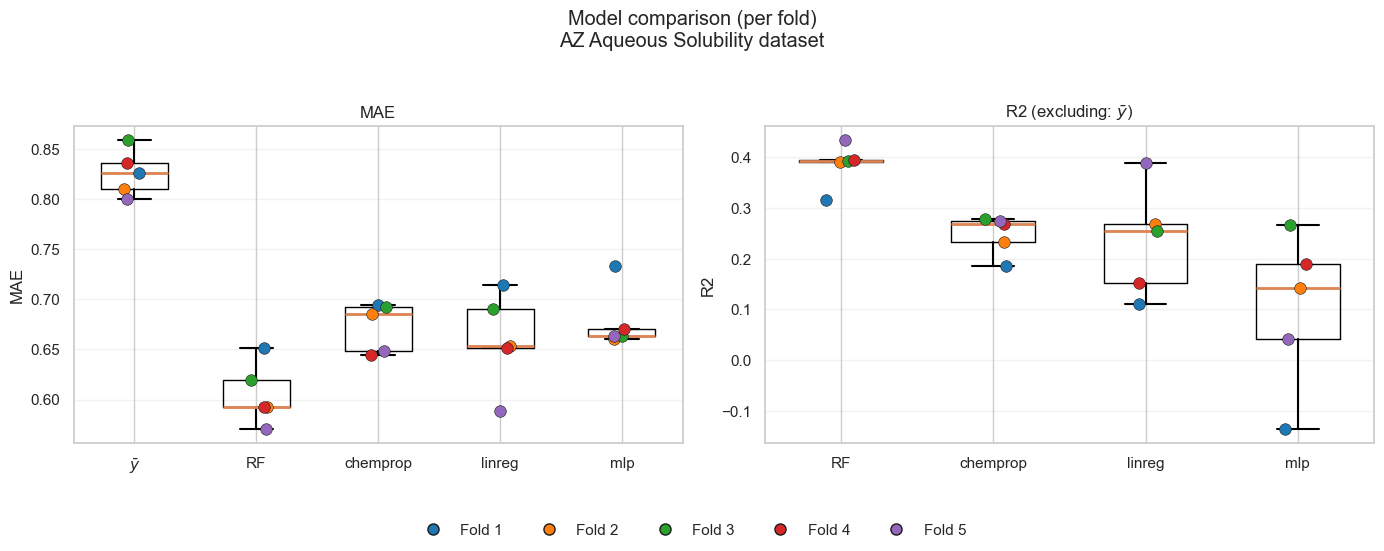

(<Figure size 1400x550 with 2 Axes>,
 array([<Axes: title={'center': 'MAE'}, ylabel='MAE'>,
        <Axes: title={'center': 'R2 (excluding: $\\bar{y}$)'}, ylabel='R2'>],
       dtype=object))

In [25]:
plot_two_panel_loose_boxplots_fold_colored(
    metrics_df,
    title=f"Model comparison (per fold)\n{DATASET_NAME} Aqueous Solubility dataset",
    left_metric="MAE",
    right_metric="R2",
    drop_from_right=[r"$\bar{y}$"],
    images_dir=images_dir,
    filename="stone_cv_spirit.png",
)


This above figure shows that all models perform better tha the basic baseline, whether in terms of MAE or $R^2$.

However, if one checks the same models but for the `BioGen` dataset, one will see that the models are not improving over the basic baseline as prominently as shown for the AZ dataset!

The difference in MAE between the box plots is not that large, and the $R^2$ is showing values at or below 0. This tells us that the new models are no better than simply predicting the mean of the sample all the time!

![image](images/evaluation_5/Biogen/stone_cv_spirit.png)

## Anchoring evaluation in better baselines.


The interesting part about the $R^2$ metric is that it divides the model's MSE by the $\bar{y}$'s MSE.

But if $\bar{y}$ is no longer the best baseline, then one can easily replace it with another model.

In the previous plots, RF is showing the lowest MAE and the highest $R^2$. ALso, form the $\alpha$ plot, it was shown that is fully dominates the basic baseline.

So, a step forward in model comparisons and decision-making is to change the baseline for this dataset from $\bar{y}$ to RF.

The below code shows a modified function for $R^2$ that does exactly this.

In [26]:
def relative_r2_from_mse(mse_new, mse_ref):
    """
    Modified R^2: 1 - (mse_new / mse_ref)
    Works with scalars or numpy arrays.
    """
    mse_new = np.asarray(mse_new, dtype=float)
    mse_ref = np.asarray(mse_ref, dtype=float)
    return 1.0 - (mse_new / mse_ref)

metrics_both = compute_model_metrics_per_fold(
    all_models,
    metrics=("RelR2",),
    relative_r2_ref_model="RF",
)

metrics_both.head()


,model,fold,n,RelR2
0,$\bar{y}$,1,353,-0.472196
1,$\bar{y}$,2,353,-0.653568
2,$\bar{y}$,3,353,-0.799644
3,$\bar{y}$,4,352,-0.694681
4,$\bar{y}$,5,352,-0.766548


And the metric now intrnisically compares the remaining three models to the RF as a baseline.

The values are below zero, which means that RF is better at predictions thant the other models. This is consistent with the plots seen above.

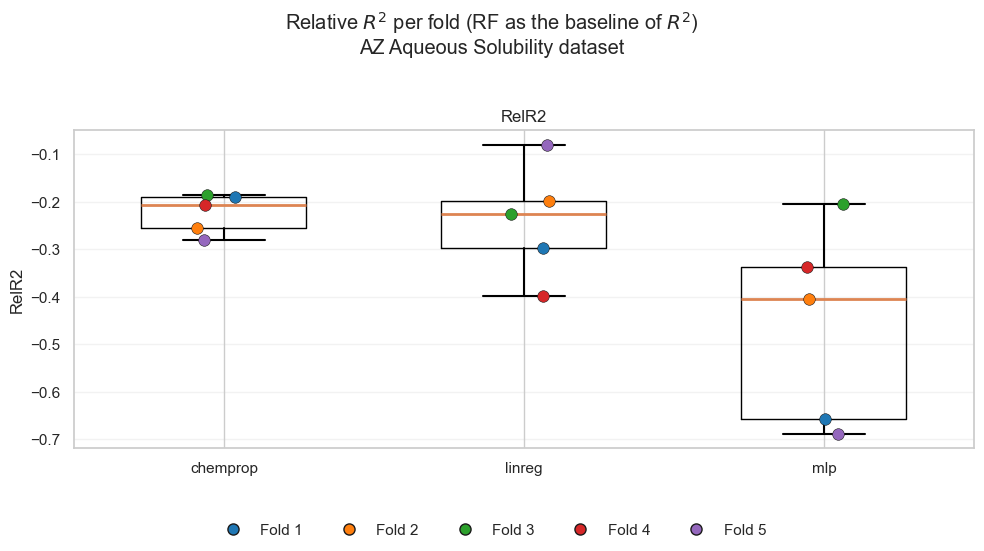

(<Figure size 1000x550 with 1 Axes>,
 <Axes: title={'center': 'RelR2'}, ylabel='RelR2'>)

In [27]:
excluded = {r"$\bar{y}$", "RF"}
left_models = [m for m in sorted(metrics_df["model"].unique()) if m not in excluded]

plot_two_panel_loose_boxplots_fold_colored(
    metrics_both,
    title=f"Relative $R^2$ per fold (RF as the baseline of $R^2$)\n{DATASET_NAME} Aqueous Solubility dataset",
    left_metric="RelR2",
    right_metric=None,
    left_models=left_models,
    images_dir=images_dir,
    filename="stone_cv_spirit_relr2.png",
)


# 5. Stone's CV as integration rather than competition - RF + Chemprop

But again, Stone's CV was not about competition rather than integration.

The best two performing models are RF and Chemprop. Instead of choosing one and throwing the other, one can think if they can be integrated.

Enter Stone's $\alpha$.

The code below generates the same plot for changing $\alpha$'s value as earlier. However, now th two models are the RF and chemprop.

The best average prediction was achieved at $\alpha = 0.2$.

This means, use both RF and Chemprop to predict a value, then listen to 80% of what RF says and 20% of what Chemprop says. This shall give a better performance that using each independently.

However, the improvement in MSE reduction is ~0.01 squared log unit. Is it worth it?

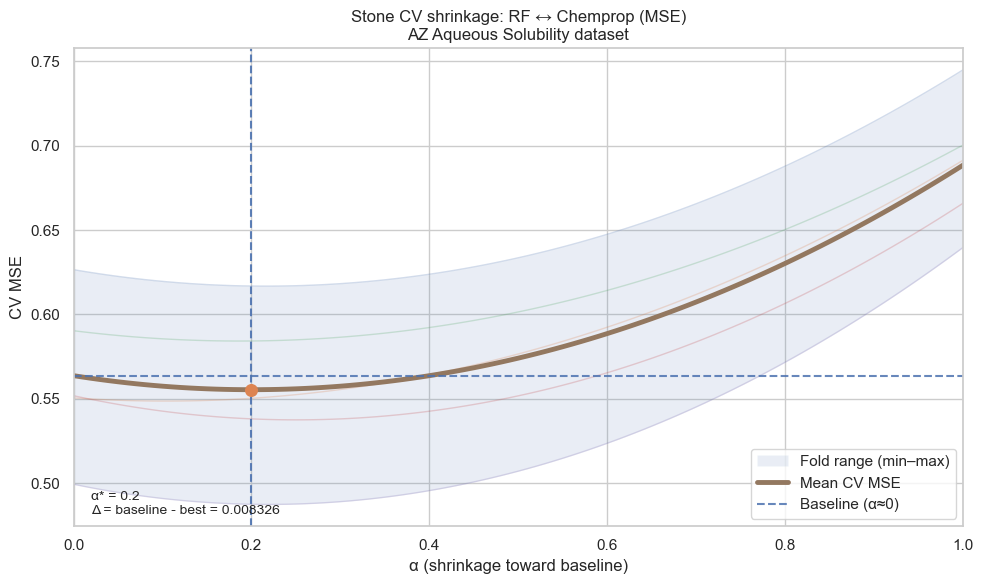

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Stone CV shrinkage: RF ↔ Chemprop (MSE)\nAZ Aqueous Solubility dataset'}, xlabel='α (shrinkage toward baseline)', ylabel='CV MSE'>)

In [28]:
results = stone_cv_alpha_path_from_preds(
    baseline_df=all_models[["idx", "fold", "y_true", "pred_RF"]],
    model_df=all_models[["idx", "pred_chemprop"]],
    baseline_pred_col="pred_RF",
    model_pred_col="pred_chemprop",
    alphas=np.linspace(0, 1, 101),
    loss="mse",
)

plot_stone_cv_alpha_path(
    results,
    title=f"Stone CV shrinkage: RF ↔ Chemprop (MSE)\n{DATASET_NAME} Aqueous Solubility dataset",
    images_dir=images_dir,
    filename="Stone_cv_RF_to_Chemprop.png",
)


Below, we repeat the visualization of the MAE, $R^2$, and RelR2 with the new hybrid model.

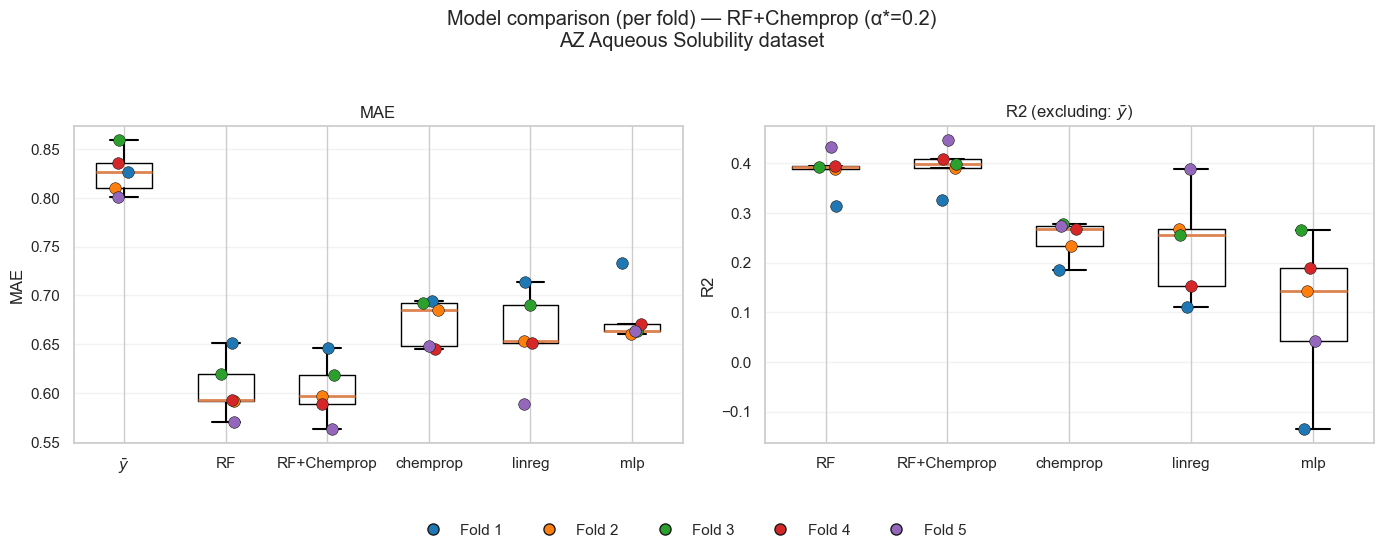

(<Figure size 1400x550 with 2 Axes>,
 array([<Axes: title={'center': 'MAE'}, ylabel='MAE'>,
        <Axes: title={'center': 'R2 (excluding: $\\bar{y}$)'}, ylabel='R2'>],
       dtype=object))

In [29]:
# 1) Build Stone ensemble preds: (1-a)*RF + a*Chemprop
a = results["best_alpha"]  # from Stone CV RF ↔ Chemprop
all_models["pred_RF+Chemprop"] = (1.0 - a) * all_models["pred_RF"] + a * all_models["pred_chemprop"]

# (optional) residuals too
all_models["resid_RF+Chemprop"] = all_models["y_true"] - all_models["pred_RF+Chemprop"]

# 2) Recompute per-fold metrics including the new model
metrics_df = compute_model_metrics_per_fold(
    all_models,
    metrics=("MAE", "MSE", "R2", "RelR2"),
    relative_r2_ref_model="RF",
)

# 3) Plot as before (exclude ybar if you want)
plot_two_panel_loose_boxplots_fold_colored(
    metrics_df,
    title=f"Model comparison (per fold) — RF+Chemprop (α*={a:.3g})\n{DATASET_NAME} Aqueous Solubility dataset",
    left_metric="MAE",
    right_metric="R2",
    drop_from_right=[r"$\bar{y}$"],
    images_dir=images_dir,
    filename="stone_cv_spirit_integrated.png",
)


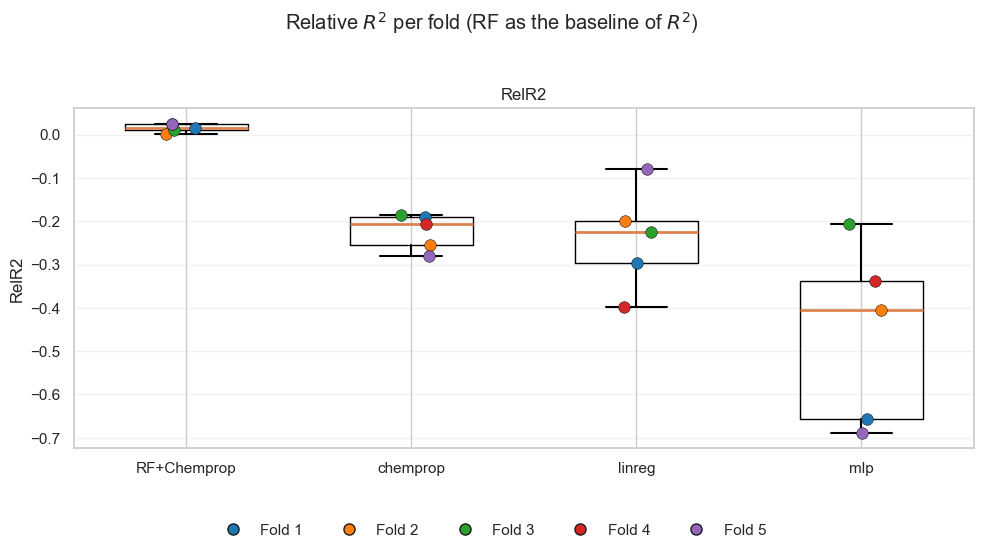

(<Figure size 1000x550 with 1 Axes>,
 <Axes: title={'center': 'RelR2'}, ylabel='RelR2'>)

In [30]:
excluded = {r"$\bar{y}$", "RF"}
left_models = [m for m in sorted(metrics_df["model"].unique()) if m not in excluded]

metrics_rel_only = metrics_df.loc[
    metrics_df["model"].isin(left_models),
    ["model", "fold", "RelR2"]
].copy()

plot_two_panel_loose_boxplots_fold_colored(
    metrics_rel_only,
    title=r"Relative $R^2$ per fold (RF as the baseline of $R^2$)",
    left_metric="RelR2",
    right_metric=None,
    left_models=left_models,
    images_dir=images_dir,
    filename="stone_cv_spirit_relr2_integrated.png",
)
